# Model Training Process Analysis

Two types of model architectures were trained on the data with 3 differenet data balancing techniques:
- none
- sampling
- weighted entrophy

Below there is an overview of training process for performed experiments.
batch size = 10
epochs = 10

In [1]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torchvision import transforms
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import numpy as np

## Test Set Performance Analysis

Evaluating ResNet and ViT models (initialized with ImageNet weights) on the held-out test sets from each experiment.


In [2]:
# ImageNet normalization for pretrained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class TestDataset(TorchDataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row["path"]).convert("RGB")
            image = image.resize((224, 224))
        except:
            image = Image.new("RGB", (224, 224))
        
        label = int(row["label"])
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [3]:
# Load test splits from all experiments
test_splits = {}
OUTPUT_DIR = "../outputs"

for exp_name in os.listdir(OUTPUT_DIR):
    exp_path = os.path.join(OUTPUT_DIR, exp_name)
    test_split_path = os.path.join(exp_path, "test_split.csv")

    if os.path.exists(test_split_path):
        test_splits[exp_name] = pd.read_csv(test_split_path)

print(f"Loaded {len(test_splits)} test splits:")
for name, df in test_splits.items():
    print(f"  - {name}: {len(df)} samples")

Loaded 8 test splits:
  - resnet_binary_none_20260505_2145: 1279 samples
  - resnet_binary_none_20260506_0437: 1279 samples
  - resnet_binary_none_20260506_0739: 1279 samples
  - resnet_binary_sampler_20260505_0118: 1279 samples
  - resnet_binary_sampler_20260506_0933: 1279 samples
  - resnet_binary_weighted_loss_20260504_2058: 1279 samples
  - resnet_binary_weighted_loss_20260505_0532: 1279 samples
  - resnet_binary_weighted_loss_20260506_1222: 1279 samples


In [6]:
def evaluate_pretrained_model(model, test_loader, device):
    """Evaluate pretrained model on test set and return predictions and labels"""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# Prepare test loaders for all experiments
OUTPUT_DIR = "../outputs"

test_loaders = {}
test_results = {}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for exp_name, test_df in test_splits.items():
    test_dataset = TestDataset(test_df, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    test_loaders[exp_name] = test_loader
    test_results[exp_name] = {}

print(f"Prepared test loaders for {len(test_loaders)} experiments.")

Prepared test loaders for 8 experiments.


In [35]:
from torchvision.models import resnet50

for exp_name, test_loader in test_loaders.items():
    print(f"\nEvaluating ResNet50 on test set from: {exp_name}")
    num_classes = len(test_splits[exp_name]["label"].unique())

    model = resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    resnet_preds, labels = evaluate_pretrained_model(model, test_loader, device)
    resnet_accuracy = accuracy_score(labels, resnet_preds)

    test_results[exp_name]["resnet50"] = {
        "accuracy": resnet_accuracy,
        "predictions": resnet_preds,
        "labels": labels,
        "num_classes": num_classes
    }

    print(f"  ResNet50 Accuracy: {resnet_accuracy:.4f}")


Evaluating ResNet50 on test set from: resnet_binary_weighted_loss_20260504_2058


c:\Users\lenaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lenaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  ResNet50 Accuracy: 0.2604


In [36]:
from torchvision.models import vit_b_16

for exp_name, test_loader in test_loaders.items():
    print(f"\nEvaluating ViT on test set from: {exp_name}")
    num_classes = len(test_splits[exp_name]["label"].unique())

    model = vit_b_16(pretrained=True)
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    model = model.to(device)

    vit_preds, labels = evaluate_pretrained_model(model, test_loader, device)
    vit_accuracy = accuracy_score(labels, vit_preds)

    test_results[exp_name]["vit"] = {
        "accuracy": vit_accuracy,
        "predictions": vit_preds,
        "labels": labels,
        "num_classes": num_classes
    }

    print(f"  ViT Accuracy: {vit_accuracy:.4f}")


Evaluating ViT on test set from: resnet_binary_weighted_loss_20260504_2058


c:\Users\lenaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lenaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  ViT Accuracy: 0.4496


Pretrained Model Performance Summary:
                               test_split    model  accuracy
resnet_binary_weighted_loss_20260504_2058      vit   0.44957
resnet_binary_weighted_loss_20260504_2058 resnet50   0.26036


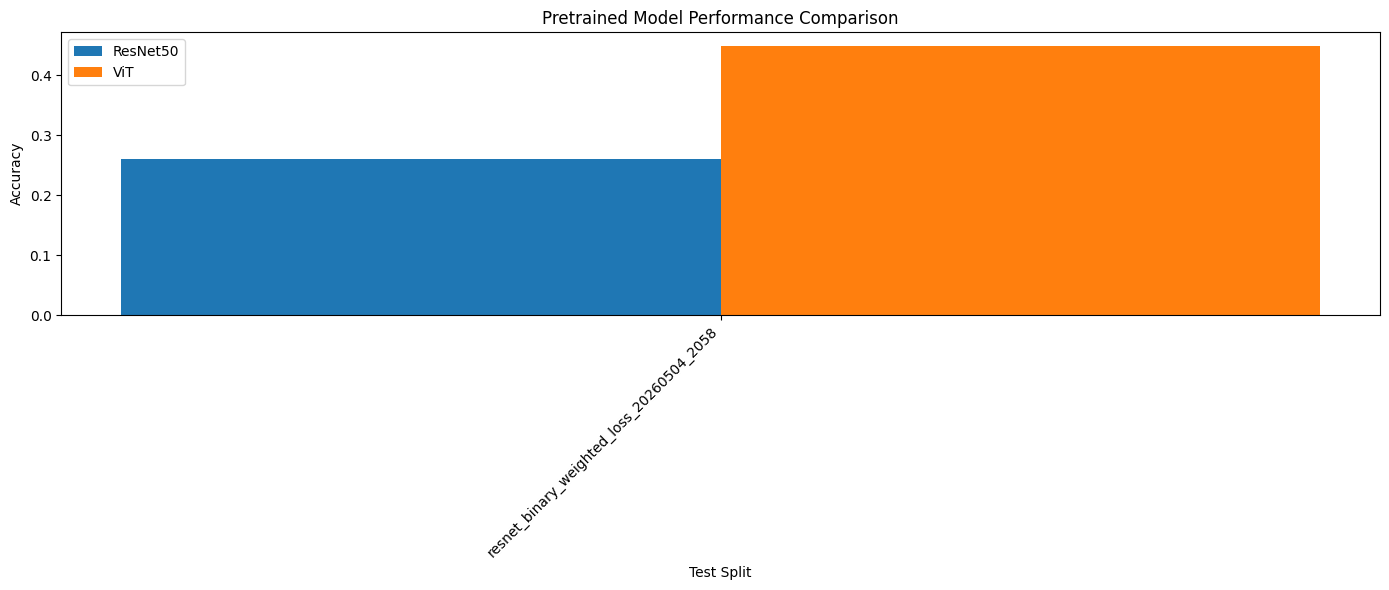

In [37]:
# Summarize pretrained model results
if test_results:
    results_summary = []
    for exp_name, models_results in test_results.items():
        for model_name, result in models_results.items():
            results_summary.append({
                "test_split": exp_name,
                "model": model_name,
                "accuracy": result["accuracy"]
            })
    
    df_test_results = pd.DataFrame(results_summary).sort_values("accuracy", ascending=False)
    print("Pretrained Model Performance Summary:")
    print(df_test_results.to_string(index=False))
    
    # Visualize pretrained model accuracies
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Group by model
    resnet_results = df_test_results[df_test_results["model"] == "resnet50"]
    vit_results = df_test_results[df_test_results["model"] == "vit"]
    
    x = np.arange(len(resnet_results))
    width = 0.35
    
    ax.bar(x - width/2, resnet_results["accuracy"], width, label="ResNet50")
    ax.bar(x + width/2, vit_results["accuracy"], width, label="ViT")
    
    ax.set_xlabel("Test Split")
    ax.set_ylabel("Accuracy")
    ax.set_title("Pretrained Model Performance Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(resnet_results["test_split"], rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()


Test Split: resnet_binary_weighted_loss_20260504_2058 | Model: RESNET50

Accuracy: 0.2604

Per-class Metrics:
              precision    recall  f1-score   support

           0       0.72      0.13      0.23      1030
           1       0.18      0.78      0.29       249

    accuracy                           0.26      1279
   macro avg       0.45      0.46      0.26      1279
weighted avg       0.61      0.26      0.24      1279



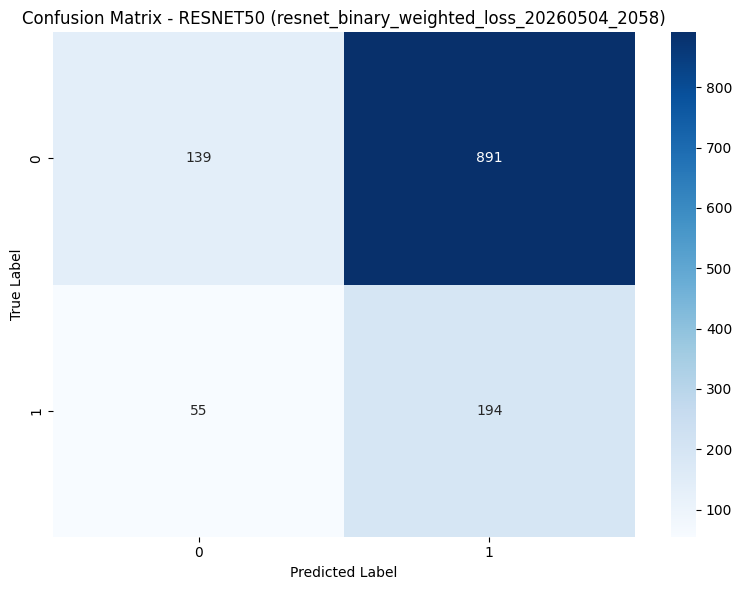


Test Split: resnet_binary_weighted_loss_20260504_2058 | Model: VIT

Accuracy: 0.4496

Per-class Metrics:
              precision    recall  f1-score   support

           0       0.78      0.44      0.56      1030
           1       0.18      0.50      0.26       249

    accuracy                           0.45      1279
   macro avg       0.48      0.47      0.41      1279
weighted avg       0.67      0.45      0.50      1279



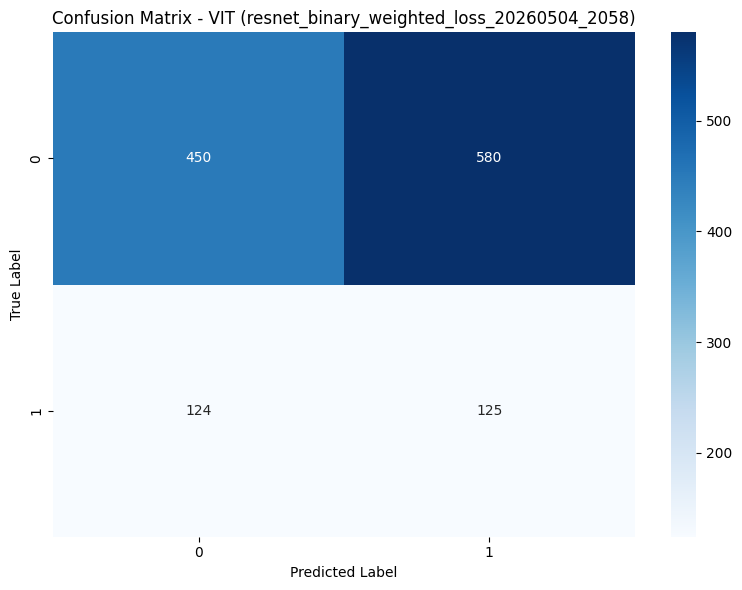

In [38]:
# Detailed per-model analysis for each test split
for exp_name, models_results in test_results.items():
    for model_name, result in models_results.items():
        preds = result["predictions"]
        labels = result["labels"]
        num_classes = result["num_classes"]
        
        print(f"\n{'='*60}")
        print(f"Test Split: {exp_name} | Model: {model_name.upper()}")
        print(f"{'='*60}")
        
        # Classification report
        class_names = [str(i) for i in range(num_classes)]
        print(f"\nAccuracy: {accuracy_score(labels, preds):.4f}")
        print("\nPer-class Metrics:")
        print(classification_report(labels, preds, target_names=class_names))
        
        # Confusion matrix
        cm = confusion_matrix(labels, preds, labels=range(num_classes))
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {model_name.upper()} ({exp_name})")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.tight_layout()
        plt.show()

Loading training data from /outputs directory, each folder corresponds to one experiment.

In [4]:
OUTPUT_DIR = "../outputs"

experiments = {}

for exp_name in os.listdir(OUTPUT_DIR):
    exp_path = os.path.join(OUTPUT_DIR, exp_name)
    
    history_path = os.path.join(exp_path, "training_history.json")
    
    if os.path.exists(history_path):
        with open(history_path) as f:
            experiments[exp_name] = json.load(f)

print("Loaded experiments:")
for name in experiments:
    print("-", name)

Loaded experiments:
- resnet_binary_none_20260502_2226
- resnet_binary_none_20260504_2137
- resnet_binary_none_20260505_2145
- resnet_binary_none_20260506_0437
- resnet_binary_none_20260506_0739
- resnet_binary_sampler_20260505_0118
- resnet_binary_sampler_20260506_0933
- resnet_binary_weighted_loss_20260430_1328
- resnet_binary_weighted_loss_20260505_0532
- resnet_binary_weighted_loss_20260506_1222


Extracting the loss from training hstory for each experiment and plotting it alongside with other experiments.

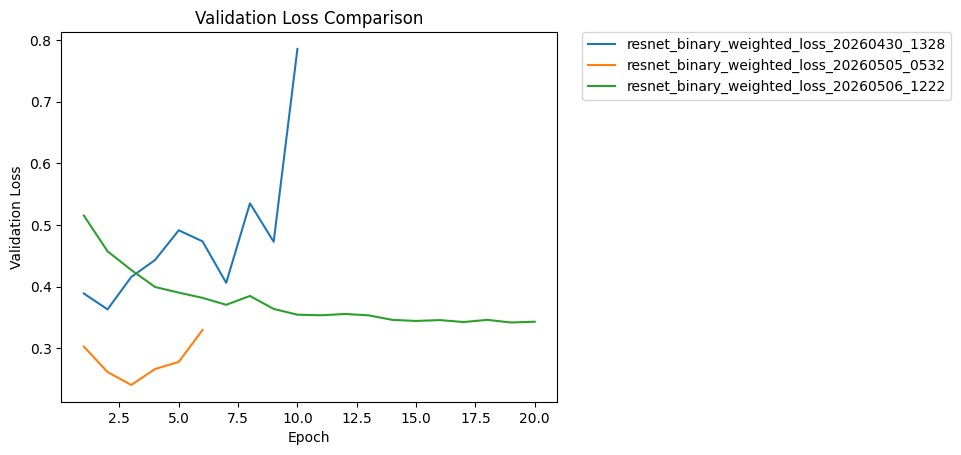

In [52]:
plt.figure()

for name, history in experiments.items():
    if "resnet_binary_w" in name:
        epochs = range(1, len(history["val_loss"]) + 1)
        plt.plot(epochs, history["val_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

Extracting the accuracy from training hstory for each experiment and plotting it alongside with other experiments.

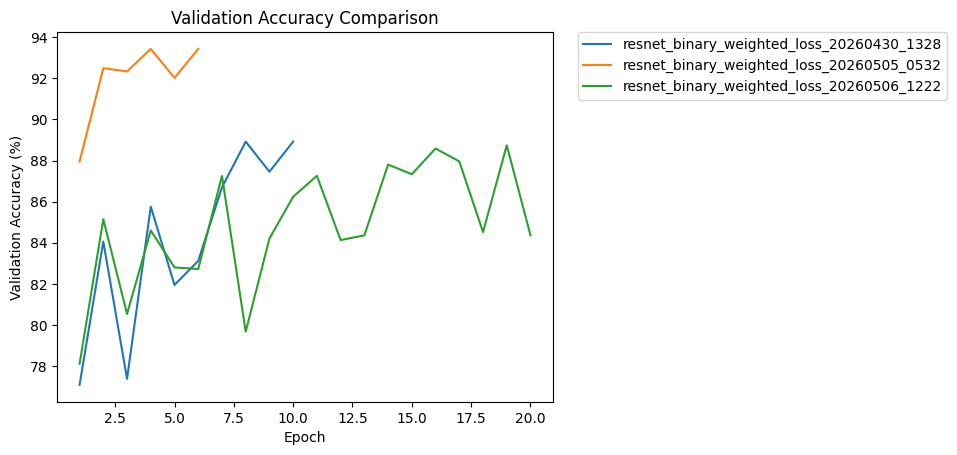

In [53]:
plt.figure()

for name, history in experiments.items():
    if "resnet_binary_w" in name:
        epochs = range(1, len(history["val_acc"]) + 1)
        plt.plot(epochs, history["val_acc"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [ ]:
results = []

for name, history in experiments.items():
    best_acc = max(history["val_acc"])
    best_epoch = history["val_acc"].index(best_acc) + 1
    
    results.append({
        "experiment": name,
        "best_acc": best_acc,
        "best_epoch": best_epoch
    })

df_results = pd.DataFrame(results)
df_results

,experiment,best_acc,best_epoch
0,resnet_binary_none_20260502_2226,91.910903,8
1,resnet_binary_none_20260504_2137,93.666927,3
2,resnet_binary_none_20260505_2145,86.161063,19
3,resnet_binary_none_20260506_0437,90.383112,14
4,resnet_binary_none_20260506_0739,92.415950,2
5,resnet_binary_sampler_20260505_0118,93.041439,6
6,resnet_binary_sampler_20260506_0933,86.395622,4
7,resnet_binary_weighted_loss_20260430_1328,88.921454,8
8,resnet_binary_weighted_loss_20260505_0532,93.432369,4
9,resnet_binary_weighted_loss_20260506_1222,88.741204,19


## Trained Models Performance on Test Data

Evaluating the best-trained models from each experiment using the shared global `outputs/test_split.csv` test set.

In [8]:
trained_model_results = {}

global_test_split_path = os.path.join(OUTPUT_DIR, "test_split.csv")
global_test_df = None
global_test_loader = None

if os.path.exists(global_test_split_path):
    global_test_df = pd.read_csv(global_test_split_path)
    global_test_loader = DataLoader(TestDataset(global_test_df, transform=test_transform), batch_size=32, shuffle=False)
    print(f"Using global test split: {global_test_split_path} ({len(global_test_df)} samples)")
else:
    print(f"Global test split not found at {global_test_split_path}. Skipping trained model evaluation.")

if global_test_loader is not None:
    num_classes = len(global_test_df["label"].unique())

    for exp_name in experiments.keys():
        exp_path = os.path.join(OUTPUT_DIR, exp_name)
        model_path = os.path.join(exp_path, "best_model.pt")

        if not os.path.exists(model_path):
            print(f"Skipping {exp_name}: model file not found", flush=True)
            continue

        try:
            # Infer model type from experiment name
            model_type = "resnet" if "resnet" in exp_name.lower() else "vit"

            if model_type == "resnet":
                from torchvision.models import resnet50
                model = resnet50(weights=None)
                model.fc = nn.Linear(model.fc.in_features, num_classes)
            else:
                from torchvision.models import vit_b_16
                model = vit_b_16(weights=None)
                model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

            model.load_state_dict(torch.load(model_path, map_location=device))
            model = model.to(device)

            preds, labels = evaluate_pretrained_model(model, global_test_loader, device)
            accuracy = accuracy_score(labels, preds)

            trained_model_results[exp_name] = {
                "accuracy": accuracy,
                "predictions": preds,
                "labels": labels,
                "num_classes": num_classes,
                "model_type": model_type
            }

            print(f"{exp_name}: Test Accuracy = {accuracy:.4f}", flush=True)

        except Exception as e:
            print(f"Error evaluating {exp_name}: {e}", flush=True)

print("\nTrained model evaluation complete!", flush=True)

Using global test split: ../outputs\test_split.csv (1279 samples)
resnet_binary_none_20260502_2226: Test Accuracy = 0.1947
resnet_binary_none_20260504_2137: Test Accuracy = 0.1947
resnet_binary_none_20260505_2145: Test Accuracy = 0.1947
resnet_binary_none_20260506_0437: Test Accuracy = 0.1947
resnet_binary_none_20260506_0739: Test Accuracy = 0.1947
resnet_binary_sampler_20260505_0118: Test Accuracy = 0.8053
resnet_binary_sampler_20260506_0933: Test Accuracy = 0.1947
resnet_binary_weighted_loss_20260430_1328: Test Accuracy = 0.1947
resnet_binary_weighted_loss_20260505_0532: Test Accuracy = 0.1947
resnet_binary_weighted_loss_20260506_1222: Test Accuracy = 0.1947

Trained model evaluation complete!
